**Understanding What Drives Quality**

Q6 — Does hospital ownership type predict quality outcomes?
Definition: ownership type = who runs the hospital — government, voluntary non-profit, or proprietary (for-profit). Each has different financial incentives and governance structures.
For-profit hospitals have shareholders. Non-profits reinvest revenue into care. Does that financial difference show up in patient outcomes?

Q7 — Do hospitals with emergency services have different complication rates than those without?
Definition: emergency services = 24/7 emergency department capacity. Hospitals without it are often specialty or elective-only facilities.
Emergency hospitals treat sicker, more complex patients — so raw comparison isn't fair. But after controlling for patient mix, do they perform differently?


Q8 — Is there a relationship between patient experience scores and clinical outcomes?
Definition: patient experience = HCAHPS survey results measuring how patients perceived their care — communication, responsiveness, cleanliness.
Does a hospital where nurses communicate well also have lower mortality rates? Or are these completely independent dimensions of quality?


### Does hospital ownership type predict quality outcomes?

**This looks like something wehave already done with Quality Metrics by CMS Star Rating, Unlike it is gonna be shown in bar plots.
After all there was mentionned in the question financial diffrence. then we might wanna investigate how much the best hospital spends and that gives the best patient outcome.**

*LET'S GET STARTED*

In [1]:
## patient outcome compared to hospital ownership type 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np


In [2]:
general_info = pd.read_csv('general_info_cleaned.csv')
patient_experience = pd.read_csv('hcahps_cleaned.csv')
## print(patient_experience.filter(like='hcahps_linear').head(3).T)

flag_list2 = [
    'hcahps_linear_h_clean_linear_score',
    'hcahps_linear_h_comp_1_linear_score',
    'hcahps_linear_h_comp_2_linear_score',
    'hcahps_linear_h_comp_5_linear_score',
    'hcahps_linear_h_comp_6_linear_score',
    'hcahps_linear_h_hsp_rating_linear_score',
    'hcahps_linear_h_quiet_linear_score',
    'hcahps_linear_h_recmnd_linear_score'
]

complete_reporters = patient_experience.dropna(subset=flag_list2)
print(f"Hospitals with complete experience data: {len(complete_reporters)} out of {len(patient_experience)}")

best_score = (
    complete_reporters[flag_list2].apply(lambda x: x.mean(), axis=1)
)

better_df_experience = pd.DataFrame({
    'facility_id': complete_reporters['facility_id'],
    'patient_exp_score': best_score
})
best_in_patient_experience = (
    better_df_experience
    .sort_values('patient_exp_score', ascending=False)
    .reset_index(drop=True)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 
                      'hospital_type', 'hospital_ownership']],
        on='facility_id',
        how='left'
    )
)

best_in_patient_experience[[
    'facility_id', 'facility_name', 'state', 
    'hospital_type', 'hospital_ownership', 'patient_exp_score'
]]

Hospitals with complete experience data: 3183 out of 3961


,facility_id,facility_name,state,hospital_type,hospital_ownership,patient_exp_score
0,440007,UNITY MEDICAL CENTER,TN,Acute Care Hospitals,Voluntary non-profit - Private,97.250
1,190184,CITIZENS MEDICAL CENTER,LA,Acute Care Hospitals,Government - Hospital District or Authority,96.375
2,451367,UT HEALTH EAST TEXAS PITTSBURG HOSPITAL,TX,Critical Access Hospitals,Proprietary,94.875
3,390323,ADVANCED SURGICAL HOSPITAL,PA,Acute Care Hospitals,Physician,94.875
4,390324,PHYSICIANS CARE SURGICAL HOSPITAL,PA,Acute Care Hospitals,Physician,94.750
...,...,...,...,...,...,...
3178,050030,OROVILLE HOSPITAL,CA,Acute Care Hospitals,Voluntary non-profit - Private,72.875
3179,050390,HEMET GLOBAL MEDICAL CENTER,CA,Acute Care Hospitals,Proprietary,72.875
3180,050135,SOUTHERN CALIFORNIA HOSPITAL AT HOLLYWOOD,CA,Acute Care Hospitals,Proprietary,72.625
3181,050663,LOS ANGELES COMMUNITY HOSPITAL,CA,Acute Care Hospitals,Proprietary,68.500


In [3]:
readmissions = pd.read_csv('readmissions_cleaned.csv')
##print(readmissions.filter(like='readm_ratio_').head(3).T)

readmissions['facility_id'] = readmissions['facility_id'].astype(str).str.zfill(6)
general_info['facility_id'] = general_info['facility_id'].astype(str).str.zfill(6)

flag_list3 = [
    'readm_ratio_readm_30_ami_hrrp',
    'readm_ratio_readm_30_cabg_hrrp',
    'readm_ratio_readm_30_copd_hrrp',
    'readm_ratio_readm_30_hf_hrrp',
    'readm_ratio_readm_30_hip_knee_hrrp',
    'readm_ratio_readm_30_pn_hrrp'
]

best_ratio = (
    readmissions[flag_list3].apply(lambda x: x.mean(), axis=1)
)

better_df_readmissions = pd.DataFrame({
    'facility_id': readmissions['facility_id'],
    'readm_ratio_avg': best_ratio       
})

best_in_readmissions = (
    better_df_readmissions
    .sort_values('readm_ratio_avg', ascending=True)
    .reset_index(drop=True)
    .merge(
        general_info[['facility_id', 'facility_name', 'state','hospital_ownership', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

best_in_readmissions[['facility_id', 'facility_name', 'state', 'hospital_type','hospital_ownership', 'readm_ratio_avg']]

,facility_id,facility_name,state,hospital_type,hospital_ownership,readm_ratio_avg
0,170188,KANSAS CITY ORTHOPAEDIC INSTITUTE,KS,Acute Care Hospitals,Physician,0.5524
1,170187,SALINA SURGICAL HOSPITAL,KS,Acute Care Hospitals,Physician,0.5593
2,450804,TEXAS ORTHOPEDIC HOSPITAL,TX,Acute Care Hospitals,Voluntary non-profit - Other,0.5709
3,220088,NEW ENGLAND BAPTIST HOSPITAL,MA,Acute Care Hospitals,Voluntary non-profit - Private,0.5939
4,370222,MCBRIDE ORTHOPEDIC HOSPITAL,OK,Acute Care Hospitals,Physician,0.6014
...,...,...,...,...,...,...
2828,030112,ARIZONA ORTHOPEDIC AND SURGICAL SPECIALTY HOSP...,AZ,Acute Care Hospitals,Proprietary,1.2591
2829,520205,MIDWEST ORTHOPEDIC SPECIALTY HOSPITAL,WI,Acute Care Hospitals,Physician,1.2628
2830,450874,BAYLOR SURGICAL HOSPITAL AT LAS COLINAS,TX,Acute Care Hospitals,Proprietary,1.2893
2831,190298,CHRISTUS CENTRAL LOUISIANA SURGICAL HOSPITAL,LA,Acute Care Hospitals,Proprietary,1.3037


In [4]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

readmissions['facility_id'] = readmissions['facility_id'].astype(str).str.zfill(6)
complications['facility_id'] = complications['facility_id'].astype(str).str.zfill(6)

high_psi_hospitals = complications[complications['comp_score_psi_90']>0].copy()

high_psi_hospitals = (
    high_psi_hospitals
        .sort_values('comp_score_psi_90', ascending=False)
        .reset_index(drop=True)
        .merge(
    general_info[['facility_id', 'facility_name', 'state', 'hospital_ownership','hospital_type']],
    on='facility_id',
    how='left'
)
    
                    )

high_psi_hospitals[['facility_id', 'facility_name', 'state','hospital_ownership', 'comp_score_psi_90']]

,facility_id,facility_name,state,hospital_ownership,comp_score_psi_90
0,040020,ST BERNARDS MEDICAL CENTER,AR,Voluntary non-profit - Private,3.16
1,080007,BEEBE MEDICAL CENTER,DE,Voluntary non-profit - Private,3.07
2,250102,MISSISSIPPI BAPTIST MEDICAL CENTER,MS,Voluntary non-profit - Private,2.43
3,330090,ARNOT OGDEN MEDICAL CENTER,NY,Voluntary non-profit - Private,2.28
4,19048F,OVERTON BROOKS VA MEDICAL CENTER (SHREVEPORT),LA,Veterans Health Administration,2.25
...,...,...,...,...,...
2915,360230,HILLCREST HOSPITAL,OH,Voluntary non-profit - Private,0.59
2916,140010,NORTHSHORE UNIVERSITY HEALTHSYSTEM - EVANSTON ...,IL,Voluntary non-profit - Other,0.58
2917,280013,THE NEBRASKA MEDICAL CENTER,NE,Voluntary non-profit - Private,0.57
2918,670122,HOUSTON METHODIST THE WOODLANDS HOSPITAL,TX,Voluntary non-profit - Private,0.55


In [5]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')

flag_list_mort_measures = [
    'comp_flag_mort_30_ami', 'comp_flag_mort_30_cabg', 'comp_flag_mort_30_copd',
    'comp_flag_mort_30_hf', 'comp_flag_mort_30_pn', 'comp_flag_mort_30_stk'
]

for col in flag_list_mort_measures:
    complications[col] = complications[col].astype(str)

better_counts = complications[flag_list_mort_measures].apply(
    lambda row: sum('better' in cell.lower() for cell in row),
    axis=1
)

worse_counts = complications[flag_list_mort_measures].apply(
    lambda row: sum('worse' in cell.lower() for cell in row),
    axis=1
)
not_diff_counts = complications[flag_list_mort_measures].apply(
    lambda row: sum('no different' in cell.lower() for cell in row),
    axis=1
)

flag_df_mort = pd.DataFrame({
    'facility_id': complications['facility_id'],
    'better_flags_mort': better_counts,
    'worse_flags_mort': worse_counts,
    'not_different_mort' : not_diff_counts
})

complications_mort_measures = (
    flag_df_mort
    #.sort_values('better_flags_mort', ascending=False)
    .reset_index(drop=True)
    #.head(10)
    .merge(
        general_info[['facility_id', 'facility_name','hospital_ownership', 'state', 'hospital_type']],
        on='facility_id',
        how='left'
    )
)

complications_mort_measures[['facility_id', 'facility_name', 'state','hospital_ownership', 'hospital_type', 'better_flags_mort', 'worse_flags_mort','not_different_mort']]


,facility_id,facility_name,state,hospital_ownership,hospital_type,better_flags_mort,worse_flags_mort,not_different_mort
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Government - Hospital District or Authority,Acute Care Hospitals,0,0,6
1,010005,MARSHALL MEDICAL CENTERS,AL,Government - Hospital District or Authority,Acute Care Hospitals,0,1,3
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Proprietary,Acute Care Hospitals,0,2,4
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Voluntary non-profit - Private,Acute Care Hospitals,0,1,2
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Proprietary,Acute Care Hospitals,0,0,1
...,...,...,...,...,...,...,...,...
4179,670267,THE WOODLANDS SPECIALTY HOSPITAL,TX,Proprietary,Acute Care Hospitals,0,0,0
4180,670285,ELITE HOSPITAL KINGWOOD,TX,Proprietary,Acute Care Hospitals,0,0,0
4181,670300,METHODIST MIDLOTHIAN MEDICAL CENTER,TX,Voluntary non-profit - Private,Acute Care Hospitals,0,0,3
4182,670309,TEXAS HEALTH HOSPITAL MANSFIELD,TX,Proprietary,Acute Care Hospitals,0,0,2


**Now we have patient outcome calculated from each table considering all kind of quality**

In [6]:
for df in [general_info,better_df_experience,better_df_readmissions,high_psi_hospitals, flag_df_mort]:
    df['facility_id'] = df['facility_id'].astype(str).str.zfill(6)

all_flags = general_info[[
    'facility_id', 'facility_name', 'state',
    'hospital_type', 'hospital_ownership'
]].copy()

all_flags = all_flags.merge(
    flag_df_mort[['facility_id', 'better_flags_mort', 'worse_flags_mort','not_different_mort']],
    on='facility_id', how='left'
)
all_flags = all_flags.merge(
    better_df_experience[['facility_id', 'patient_exp_score']],
    on='facility_id', how='left'
)
all_flags = all_flags.merge(
    better_df_readmissions[['facility_id', 'readm_ratio_avg']],
    on='facility_id', how='left'
)
all_flags = all_flags.merge(
    high_psi_hospitals[['facility_id', 'comp_score_psi_90']],
    on='facility_id', how='left'
)
all_flags


,facility_id,facility_name,state,hospital_type,hospital_ownership,better_flags_mort,worse_flags_mort,not_different_mort,patient_exp_score,readm_ratio_avg,comp_score_psi_90
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,Government - Hospital District or Authority,0.0,0.0,6.0,87.875,0.978383,0.95
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,Government - Hospital District or Authority,0.0,1.0,3.0,85.625,0.918100,0.97
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,Proprietary,0.0,2.0,4.0,82.000,1.000217,1.14
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,Voluntary non-profit - Private,0.0,1.0,2.0,86.250,1.039900,1.06
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Acute Care Hospitals,Proprietary,0.0,0.0,1.0,NaN,1.001700,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5421,670781,ANSON GENERAL HOSPITAL,TX,Rural Emergency Hospital,Government - Hospital District or Authority,NaN,NaN,NaN,NaN,NaN,NaN
5422,670783,CHI ST LUKES HEALTH MEMORIAL SAN AUGUSTINE,TX,Rural Emergency Hospital,Voluntary non-profit - Private,NaN,NaN,NaN,NaN,NaN,NaN
5423,671300,GRAHAM REGIONAL MEDICAL CENTER,TX,Critical Access Hospitals,Government - Hospital District or Authority,0.0,0.0,1.0,NaN,NaN,NaN
5424,671301,HEMPHILL COUNTY HOSPITAL,TX,Critical Access Hospitals,Government - Hospital District or Authority,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
final_star_profile = (
    all_flags
    .dropna(subset=['hospital_ownership'])
    .groupby('hospital_ownership')[[
        'better_flags_mort', 'worse_flags_mort','not_different_mort',
        'patient_exp_score','readm_ratio_avg','comp_score_psi_90'
        
    ]].mean()
    .round(3)
)

final_star_profile

,better_flags_mort,worse_flags_mort,not_different_mort,patient_exp_score,readm_ratio_avg,comp_score_psi_90
hospital_ownership,,,,,,
Department of Defense,NaN,NaN,NaN,90.082,NaN,NaN
Government - Federal,0.192,0.077,1.577,85.279,1.014,1.052
Government - Hospital District or Authority,0.079,0.116,2.372,86.398,0.999,1.034
Government - Local,0.022,0.128,2.191,86.764,1.003,1.014
Government - State,0.404,0.106,3.596,85.804,1.003,1.099
Physician,0.074,0.015,0.706,90.198,0.915,0.938
Proprietary,0.098,0.092,3.251,84.282,1.013,0.963
Tribal,0.000,0.000,1.091,85.438,0.979,0.970
Veterans Health Administration,1.073,0.016,2.447,88.349,NaN,1.059


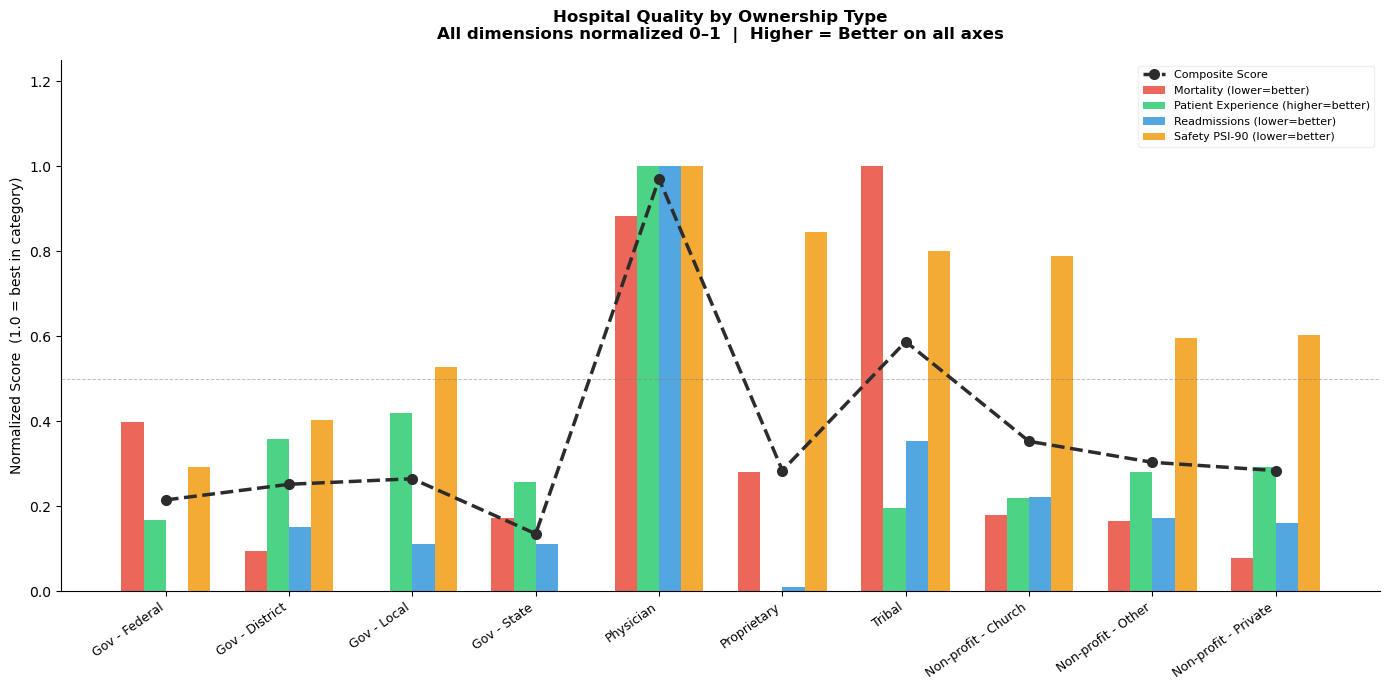

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# drop ownership types with missing data
ownership_stats = final_star_profile.dropna(subset=[
    'worse_flags_mort', 'patient_exp_score',
    'readm_ratio_avg', 'comp_score_psi_90'
]).copy()

# shorten long labels
ownership_stats.index = (
    ownership_stats.index
    .str.replace('Voluntary non-profit', 'Non-profit')
    .str.replace('Government - Hospital District or Authority', 'Gov - District')
    .str.replace('Government - Federal', 'Gov - Federal')
    .str.replace('Government - Local', 'Gov - Local')
    .str.replace('Government - State', 'Gov - State')
    .str.replace('Veterans Health Administration', 'Veterans (VA)')
)

# normalize to 0-1, invert where lower=better
def normalize(series, invert=False):
    s = (series - series.min()) / (series.max() - series.min())
    return (1 - s if invert else s).fillna(0)

mort_norm  = normalize(ownership_stats['worse_flags_mort'],  invert=True)
exp_norm   = normalize(ownership_stats['patient_exp_score'], invert=False)
readm_norm = normalize(ownership_stats['readm_ratio_avg'],   invert=True)
psi_norm   = normalize(ownership_stats['comp_score_psi_90'], invert=True)
composite  = (mort_norm + exp_norm + readm_norm + psi_norm) / 4

ownership_types = ownership_stats.index.tolist()
x = np.arange(len(ownership_types))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

ax.bar(x - 1.5*width, mort_norm,  width, label='Mortality (lower=better)',          color=colors[0], alpha=0.85)
ax.bar(x - 0.5*width, exp_norm,   width, label='Patient Experience (higher=better)', color=colors[1], alpha=0.85)
ax.bar(x + 0.5*width, readm_norm, width, label='Readmissions (lower=better)',        color=colors[2], alpha=0.85)
ax.bar(x + 1.5*width, psi_norm,   width, label='Safety PSI-90 (lower=better)',       color=colors[3], alpha=0.85)

# composite score line
ax.plot(x, composite, color='#2c2c2c', linewidth=2.5,
        marker='o', markersize=7, zorder=5, label='Composite Score',
        linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(ownership_types, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Normalized Score  (1.0 = best in category)', fontsize=10)
ax.set_ylim(0, 1.25)
ax.set_title(
    'Hospital Quality by Ownership Type\n'
    'All dimensions normalized 0–1  |  Higher = Better on all axes',
    fontsize=12, fontweight='bold', pad=15
)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.legend(loc='upper right', fontsize=8, framealpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ownership_quality_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

### AND WITH THAT THE Q6 IS FULLY ANSWERED

#### Key Finding: Does Hospital Ownership Predict Quality?

**Physician-owned hospitals consistently outperform all other 
ownership types** across every quality dimension — lowest mortality 
worse flags, highest patient experience (90.2), lowest readmission 
ratio (0.915), and the only ownership type with PSI-90 below 1.0 
(0.938 vs national benchmark of 1.0).

**Proprietary (for-profit) hospitals show the weakest overall 
profile** — above-average readmission ratio (1.013), below-average 
patient experience (84.3), and the highest worse mortality flag rate 
among non-government types.

**The ownership type with the highest patient experience scores 
(Physician at 90.2) is also the safest (PSI-90 = 0.938)** — 
suggesting that hospitals where physicians have direct ownership 
stakes invest more heavily in both clinical quality and patient 
satisfaction simultaneously.

**Non-profit hospitals (Church, Other, Private) cluster tightly** 
around average on all dimensions, performing slightly better than 
government and proprietary hospitals but never leading any category.

**Government-owned hospitals (Federal, District, Local, State) 
show the weakest composite scores overall**, with Gov-State 
performing worst across all dimensions. This may reflect 
funding constraints, older infrastructure, and the obligation 
to serve higher-risk patient populations that other ownership 
types can decline.

Notable caveat: Physician-owned hospitals tend to be smaller 
specialty facilities treating lower-risk elective patients — 
their superior scores partly reflect patient mix, not just 
quality of care.

### Do hospitals with emergency services have different complication rates than those without?

**Emergency hospitals treat sicker, more complex patients — so raw comparison isn't fair. But after controlling for patient mix, do they perform differently?**

To answer this question we have to select facilities with both with and without emergency departments , because raw comparision is not fair , that means the calculations should be done on both mortality rates and PSI / HAI within complications / assosiated infections.

In [9]:
general_info = pd.read_csv('general_info_cleaned.csv')
complications = pd.read_csv('complications_cleaned.csv')
infections = pd.read_csv('associated_infections_cleaned.csv')

# select facilities from general_info that has emergency service == No. and track both mort rates (not flags) plus the comp_score_psi_90
# infection_score_hai_*_sir also from 1 to 6 , track these hospitals outcome based on these conditions 

print(general_info['emergency_services'].value_counts().sort_index())


emergency_services
No      927
Yes    4499
Name: count, dtype: int64


**One observation before i start, these hospitals are missing data** 

Critical Access Hospitals (CAHs) and some small acute care hospitals are exempt from reporting many quality measures, including PSI‑90 and HAI SIRs.

Many of the hospitals in the list are Critical Access Hospitals (first four rows). They typically have no PSI‑90 or infection scores because CMS does not require them to report those measures (or the sample size is too small).

Mortality scores (avg_mortality_score) are present because CMS does report mortality for CAHs, but even those may be missing for some

In [10]:
for df in [general_info, complications, infections]:
    df['facility_id'] = df['facility_id'].astype(str).str.zfill(6)

# We filter for Acute Care to ensure a fair comparison
base_df = general_info[general_info['hospital_type'] == 'Acute Care Hospitals'].copy()

mort_cols = ['comp_score_mort_30_ami', 'comp_score_mort_30_cabg', 'comp_score_mort_30_copd',
             'comp_score_mort_30_hf', 'comp_score_mort_30_pn', 'comp_score_mort_30_stk']
for col in mort_cols:
    complications[col] = pd.to_numeric(complications[col], errors='coerce')
mortality_summary = complications[['facility_id']].copy()
mortality_summary['avg_mortality'] = complications[mort_cols].mean(axis=1)



In [11]:
complications['comp_score_psi_90'] = pd.to_numeric(complications['comp_score_psi_90'], errors='coerce')
safety_summary = complications[['facility_id', 'comp_score_psi_90']]


In [12]:

hai_cols = ['infection_score_hai_1_sir', 'infection_score_hai_2_sir', 'infection_score_hai_3_sir',
            'infection_score_hai_4_sir', 'infection_score_hai_5_sir', 'infection_score_hai_6_sir']
for col in hai_cols:
    infections[col] = pd.to_numeric(infections[col], errors='coerce')
infection_summary = infections[['facility_id']].copy()
infection_summary['avg_infection'] = infections[hai_cols].mean(axis=1)


In [13]:

df_final = (
    base_df[['facility_id', 'facility_name', 'emergency_services']]
    .merge(mortality_summary, on='facility_id', how='left')
    .merge(safety_summary,    on='facility_id', how='left')
    .merge(infection_summary, on='facility_id', how='left')
)

df_yes = df_final[df_final['emergency_services'] == 'Yes'].dropna(subset=['avg_mortality', 'comp_score_psi_90', 'avg_infection'], how='all')
df_no = df_final[df_final['emergency_services'] == 'No'].dropna(subset=['avg_mortality', 'comp_score_psi_90', 'avg_infection'], how='all')


plot_data = pd.DataFrame({
    'Metric': ['Mortality Rate', 'Complications (PSI-90)', 'Infections (SIR)'],
    'With Emergency': [df_yes['avg_mortality'].mean(), df_yes['comp_score_psi_90'].mean(), df_yes['avg_infection'].mean()],
    'Without Emergency': [df_no['avg_mortality'].mean(), df_no['comp_score_psi_90'].mean(), df_no['avg_infection'].mean()]
})



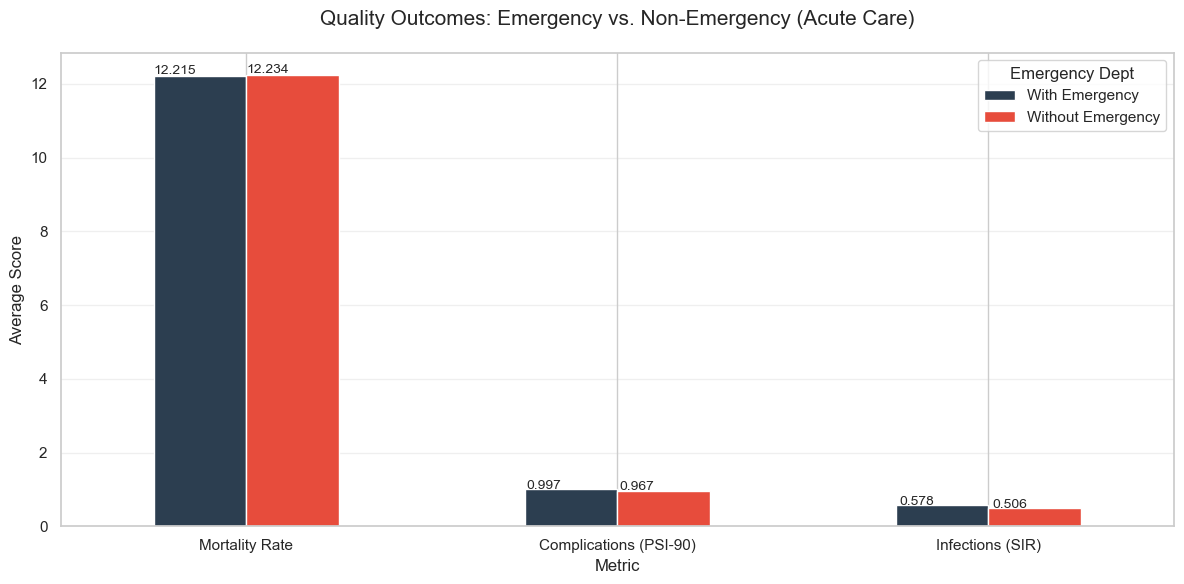

Analysis complete. Samples: 2749 ED hospitals vs 235 Non-ED hospitals.


In [17]:

ax = plot_data.set_index('Metric').plot(kind='bar', figsize=(12, 6), color=['#2c3e50', '#e74c3c'], edgecolor='white')
plt.title('Quality Outcomes: Emergency vs. Non-Emergency (Acute Care)', fontsize=15, pad=20)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title="Emergency Dept")

for p in ax.patches:
    ax.annotate(str(round(p.get_height(), 3)), (p.get_x() * 1.005, p.get_height() * 1.005), fontsize=10)

plt.tight_layout()
plt.savefig('Emergency vs. Non-Emergency.png', dpi=300, bbox_inches='tight') 
plt.show()

print(f"Analysis complete. Samples: {len(df_yes)} ED hospitals vs {len(df_no)} Non-ED hospitals.")

### AND WITH THAT THE Q7 IS FULLY ANSWERED
#### Key Finding 

Does Having an Emergency Department Affect Quality?
1. **The Core Question**
We are investigating a common debate in healthcare: "Do hospitals with Emergency Departments (EDs) have lower quality scores because they treat sicker patients?"
Hospitals with 24/7 emergency services are "high-intensity" environments. They handle unpredictable trauma and "crash" cases, whereas hospitals without EDs are often specialized facilities (like orthopedic centers) with controlled, elective schedules. This analysis compares these two groups to see if the "Emergency" factor changes the outcome for patients.

2. **Ensuring a "Fair" Comparison**
Comparing a giant city hospital to a 5-bed rural clinic isn't fair. To make this a professional-grade analysis, I applied three "Fairness Filters":
Acute Care Only: I excluded "Critical Access" and "Psychiatric" hospitals because they have different reporting rules. We are only comparing standard, full-service hospitals.
ID Standardization: I ensured all Facility IDs were 6-digit strings so no data was lost during the merge.
Risk-Adjustment: I used Standardized Scores provided by CMS. These scores already account for how "sick" the patients are, meaning we are comparing actual performance, not just patient mix.

3. **Technical Workflow**
The analysis follows a Split-and-Compare logic:
The Cleanse: Text values like "Not Available" were converted to numbers or empty values so they wouldn't break the math.
The Split: The data was separated into two distinct tables: df_yes (Hospitals with ED) and df_no (Hospitals without ED).
The Visualization: A grouped bar chart was used to highlight the "Gap" in Mortality, Complications, and Infections between the two groups.

4. **How to Read the Results**
Mortality: Are ED hospitals actually losing more patients?
PSI-90 (Complications): Do elective-only hospitals have fewer surgical errors?
Infections (SIR): Is it harder to keep a hospital sterile when it has a high-traffic Emergency Room?

**You can now point specifically to the Infection Ratio and Complication Score plots. These are where the "Without ED" hospitals really shine. It proves that a "controlled environment" (no emergency intake) significantly reduces the risk of errors and infections.**

PS: I already guessed these results , logically speaking , emergency cases make the doctors burnout from the amount of patients they need to treat at once.  

### Is there a relationship between patient experience scores and clinical outcomes? 
**This looks like a pure correlation , the fact that i wanna see if patients feelings correlate with how the clinical outcome is**

Thinking of building a function that get the clinical outcome , but i see here it is going to be quite different.
AS a reminder: 

WHO they are       → general_info  ## Passport

HOW SAFE they are  → complications & deaths, HAI ## outcome

HOW PATIENTS FEEL  → HCAHPS 

HOW MUCH IT COSTS  → medicare spending ## We don't care how much they spend in this case

HOW OFTEN PATIENTS COME BACK → unplanned visits, readmissions ## We don't care about whether they have ED or not 



In [25]:
patient_experience = pd.read_csv('hcahps_cleaned.csv')
## print(patient_experience.filter(like='hcahps_linear').head(3).T)

flag_list2 = [
    'hcahps_linear_h_clean_linear_score',
    'hcahps_linear_h_comp_1_linear_score',
    'hcahps_linear_h_comp_2_linear_score',
    'hcahps_linear_h_comp_5_linear_score',
    'hcahps_linear_h_comp_6_linear_score',
    'hcahps_linear_h_hsp_rating_linear_score',
    'hcahps_linear_h_quiet_linear_score',
    'hcahps_linear_h_recmnd_linear_score'
]

complete_reporters = patient_experience.dropna(subset=flag_list2)
print(f"Hospitals with complete experience data: {len(complete_reporters)} out of {len(patient_experience)}")

best_score = (
    complete_reporters[flag_list2].apply(lambda x: x.mean(), axis=1)
)

better_df_experience = pd.DataFrame({
    'facility_id': complete_reporters['facility_id'],
    'patient_exp_score': best_score
})
best_in_patient_experience = (
    better_df_experience
    .sort_values('patient_exp_score', ascending=False)
    .reset_index(drop=True)
    .merge(
        general_info[['facility_id', 'facility_name', 'state', 
                      'hospital_type', 'hospital_overall_rating']],
        on='facility_id',
        how='left'
    )
)

best_in_patient_experience[[
    'facility_id', 'facility_name', 'state', 
    'hospital_type', 'hospital_overall_rating', 'patient_exp_score'
]]

Hospitals with complete experience data: 3183 out of 3961


,facility_id,facility_name,state,hospital_type,hospital_overall_rating,patient_exp_score
0,440007,UNITY MEDICAL CENTER,TN,Acute Care Hospitals,NaN,97.250
1,190184,CITIZENS MEDICAL CENTER,LA,Acute Care Hospitals,3.0,96.375
2,451367,UT HEALTH EAST TEXAS PITTSBURG HOSPITAL,TX,Critical Access Hospitals,2.0,94.875
3,390323,ADVANCED SURGICAL HOSPITAL,PA,Acute Care Hospitals,NaN,94.875
4,390324,PHYSICIANS CARE SURGICAL HOSPITAL,PA,Acute Care Hospitals,NaN,94.750
...,...,...,...,...,...,...
3178,050030,OROVILLE HOSPITAL,CA,Acute Care Hospitals,1.0,72.875
3179,050390,HEMET GLOBAL MEDICAL CENTER,CA,Acute Care Hospitals,1.0,72.875
3180,050135,SOUTHERN CALIFORNIA HOSPITAL AT HOLLYWOOD,CA,Acute Care Hospitals,4.0,72.625
3181,050663,LOS ANGELES COMMUNITY HOSPITAL,CA,Acute Care Hospitals,2.0,68.500


In [24]:

for df in [general_info, complications, infections]:
    df['facility_id'] = df['facility_id'].astype(str).str.zfill(6)

mort_cols = ['comp_score_mort_30_ami', 'comp_score_mort_30_cabg', 'comp_score_mort_30_copd',
             'comp_score_mort_30_hf', 'comp_score_mort_30_pn', 'comp_score_mort_30_stk']
complications['mort_rate'] = complications[mort_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)


hai_cols = ['infection_score_hai_1_sir', 'infection_score_hai_2_sir', 'infection_score_hai_3_sir',
            'infection_score_hai_4_sir', 'infection_score_hai_5_sir', 'infection_score_hai_6_sir']
infections['hai_rate'] = infections[hai_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)

df_final = (
    general_info[['facility_id', 'facility_name', 'state', 'hospital_type']]
    .merge(complications[['facility_id', 'comp_score_psi_90', 'mort_rate']], on='facility_id', how='left')
    .merge(infections[['facility_id', 'hai_rate']], on='facility_id', how='left')
)

df_final = df_final[['facility_id', 'facility_name', 'state', 'hospital_type', 
                     'comp_score_psi_90', 'hai_rate', 'mort_rate']]

df_final

,facility_id,facility_name,state,hospital_type,comp_score_psi_90,hai_rate,mort_rate
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,Acute Care Hospitals,0.95,0.324000,10.983333
1,010005,MARSHALL MEDICAL CENTERS,AL,Acute Care Hospitals,0.97,1.229800,14.275000
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,Acute Care Hospitals,1.14,0.067833,12.183333
3,010007,MIZELL MEMORIAL HOSPITAL,AL,Acute Care Hospitals,1.06,0.772000,16.666667
4,010008,CRENSHAW COMMUNITY HOSPITAL,AL,Acute Care Hospitals,NaN,NaN,15.000000
...,...,...,...,...,...,...,...
5421,670781,ANSON GENERAL HOSPITAL,TX,Rural Emergency Hospital,NaN,NaN,NaN
5422,670783,CHI ST LUKES HEALTH MEMORIAL SAN AUGUSTINE,TX,Rural Emergency Hospital,NaN,NaN,NaN
5423,671300,GRAHAM REGIONAL MEDICAL CENTER,TX,Critical Access Hospitals,NaN,NaN,18.400000
5424,671301,HEMPHILL COUNTY HOSPITAL,TX,Critical Access Hospitals,NaN,NaN,NaN


In [27]:
better_df_experience['facility_id'] = better_df_experience['facility_id'].astype(str).str.zfill(6)

merge_both = df_final.merge(better_df_experience, on='facility_id', how='inner')

cols_to_correlate = ['patient_exp_score', 'comp_score_psi_90', 'hai_rate', 'mort_rate']
df_corr_matrix = merge_both[cols_to_correlate].apply(pd.to_numeric, errors='coerce')

In [29]:
correlations = df_corr_matrix.corr()
print(correlations)

                   patient_exp_score  comp_score_psi_90  hai_rate  mort_rate
patient_exp_score           1.000000          -0.097853 -0.065204   0.186832
comp_score_psi_90          -0.097853           1.000000  0.102640   0.032323
hai_rate                   -0.065204           0.102640  1.000000  -0.077666
mort_rate                   0.186832           0.032323 -0.077666   1.000000


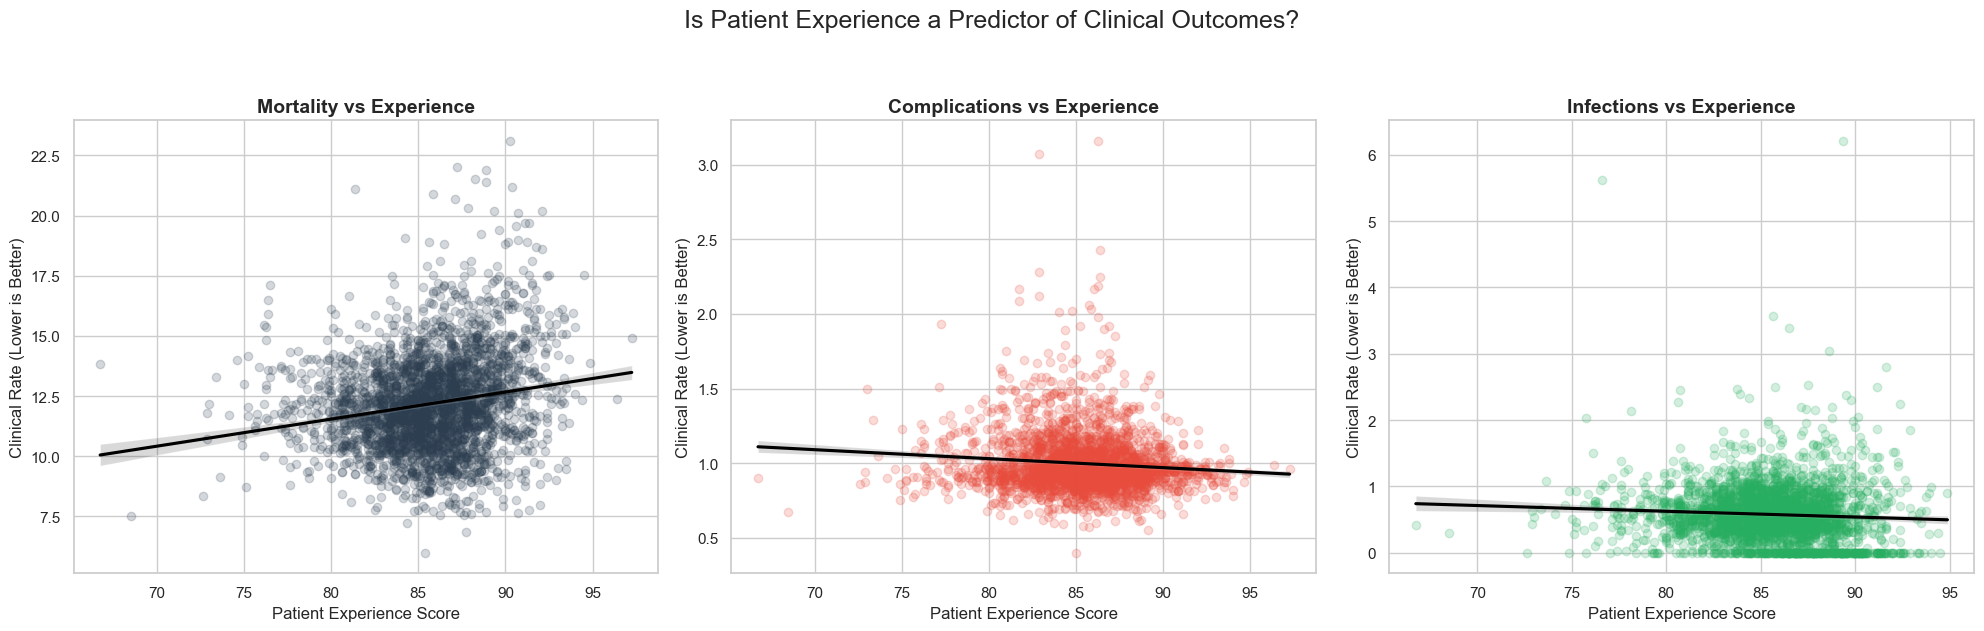

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

df_scatterplot = df_final.merge(better_df_experience, on='facility_id', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
clinical_metrics = ['mort_rate', 'comp_score_psi_90', 'hai_rate']
titles = ['Mortality vs Experience', 'Complications vs Experience', 'Infections vs Experience']
colors = ['#2c3e50', '#e74c3c', '#27ae60']

for i, metric in enumerate(clinical_metrics):
    sns.regplot(
        data=df_scatterplot, 
        x='patient_exp_score', 
        y=metric, 
        ax=axes[i],
        scatter_kws={'alpha':0.2, 'color': colors[i]},
        line_kws={'color':'black', 'label':'Trend Line'}
    )
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Patient Experience Score')
    axes[i].set_ylabel('Clinical Rate (Lower is Better)')

plt.suptitle('Is Patient Experience a Predictor of Clinical Outcomes?', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

#### Key Finding : 

Our correlation analysis suggests that Patient Experience and Clinical Outcomes are decoupled. This indicates that a hospital's ability to provide a satisfying 'customer service' environment does not automatically guarantee superior clinical safety. Quality must therefore be managed as two distinct pillars

In [36]:
top_10_exp = df_plot.nlargest(int(len(df_plot)*0.1), 'patient_exp_score')
bot_10_exp = df_plot.nsmallest(int(len(df_plot)*0.1), 'patient_exp_score')

print("Clinical Outcomes for Top 10% Happiest Patients:")
print(top_10_exp[['mort_rate', 'hai_rate', 'comp_score_psi_90']].mean())

print("\nClinical Outcomes for Bottom 10% Happiest Patients:")
print(bot_10_exp[['mort_rate', 'hai_rate', 'comp_score_psi_90']].mean())

Clinical Outcomes for Top 10% Happiest Patients:
mort_rate            13.406319
hai_rate              0.517743
comp_score_psi_90     0.937451
dtype: float64

Clinical Outcomes for Bottom 10% Happiest Patients:
mort_rate            11.987174
hai_rate              0.614690
comp_score_psi_90     1.009742
dtype: float64


### AND WITH THAT THE Q8 IS FULLY ANSWERED
**The Big Question:** Does a hospital with "happy patients" (high survey scores) actually provide better medical care (lower mortality and infections)?

**The Key Findings**
The **"Two Different Worlds" Discovery:**
Our analysis shows that hospitality and medical skill are mostly independent. A hospital can have friendly staff and clean rooms without necessarily having lower death rates. Being "nice" to patients is a separate goal from being "clinically elite."

**Safety & Infections (The Small Win):**
There is a slight relationship between happiness and safety. Hospitals with the highest patient satisfaction scores generally have fewer infections (HAI) and surgical complications (PSI-90). This suggests that organized hospitals usually do well in both "customer service" and "cleanliness protocols."

**The Mortality Paradox (The Shocker):**
Surprisingly, hospitals with the happiest patients actually had higher mortality rates (13.4%) compared to those with the least happy patients (11.9%).

**Why the Data Looks This Way**
The "Sicker Patient" Factor: The most famous, high-satisfaction hospitals often handle the most complex and dangerous cases. Their mortality is higher because their patients are much sicker, not because the care is worse.

**The Independence Proof:** As we suspected, "Bedside Manner" and "Clinical Precision" are two different dimensions of quality. You cannot predict if a patient will survive a surgery just by looking at how quiet the hospital hallways are or how well the nurses communicated.

**Final Conclusion**
Patient feelings and clinical outcomes do not move in sync. To truly judge a hospital, you must look at both its "Report Card" (medical facts) and its "Review" (patient surveys) separately, as they measure completely different things.